In [1]:
import requests
import pandas as pd

url = "https://api.binance.com/api/v3/klines"
params = {"symbol": "BTCUSDT", "interval": "1d", "limit": 365}
response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data, columns=[
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "trades",
    "taker_buy_base", "taker_buy_quote", "ignore"
])
df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
df[["open","high","low","close","volume"]] = df[["open","high","low","close","volume"]].astype(float)
df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,trades,taker_buy_base,taker_buy_quote,ignore
0,2025-09-09,112065.23,113293.29,110766.66,111546.39,15379.28248,1757462399999,1721465997.90636600,2143242,7597.38038000,849973176.17756840,0
1,2025-09-10,111546.38,114313.13,110917.45,113960.00,17517.41823,1757548799999,1978834750.22231150,2182534,8274.63998000,934646697.48233240,0
2,2025-09-11,113960.00,115488.09,113430.00,115482.69,13676.73119,1757635199999,1562241144.95654100,2166359,6744.29993000,770595422.69052130,0
3,2025-09-12,115482.69,116665.63,114740.99,116029.42,15324.10719,1757721599999,1772122269.50186350,2481491,7995.57276000,924775389.85693960,0
4,2025-09-13,116029.41,116298.78,115127.27,115918.29,8269.40394,1757807999999,957724220.64976110,1223635,3590.09359000,415773029.43935270,0


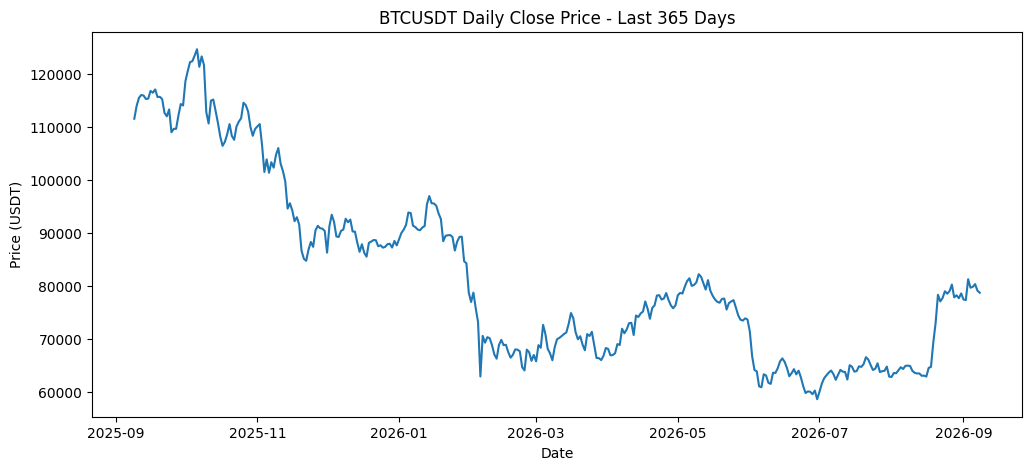

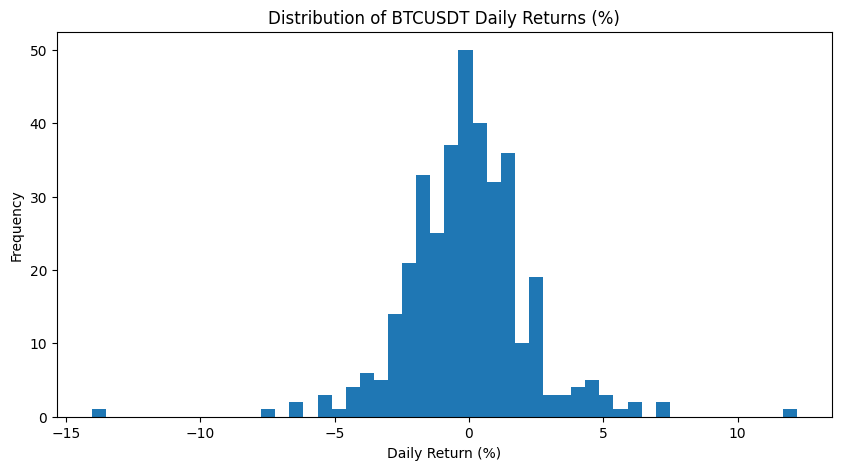

Mean daily return: -0.07%
Std dev (volatility): 2.32%
Max single-day gain: 12.19%
Max single-day loss: -14.02%


In [2]:
import matplotlib.pyplot as plt

# Price over time
plt.figure(figsize=(12,5))
plt.plot(df["open_time"], df["close"])
plt.title("BTCUSDT Daily Close Price - Last 365 Days")
plt.xlabel("Date")
plt.ylabel("Price (USDT)")
plt.show()

# Daily returns
df["daily_return"] = df["close"].pct_change() * 100

plt.figure(figsize=(10,5))
plt.hist(df["daily_return"].dropna(), bins=50)
plt.title("Distribution of BTCUSDT Daily Returns (%)")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.show()

print(f"Mean daily return: {df['daily_return'].mean():.2f}%")
print(f"Std dev (volatility): {df['daily_return'].std():.2f}%")
print(f"Max single-day gain: {df['daily_return'].max():.2f}%")
print(f"Max single-day loss: {df['daily_return'].min():.2f}%")

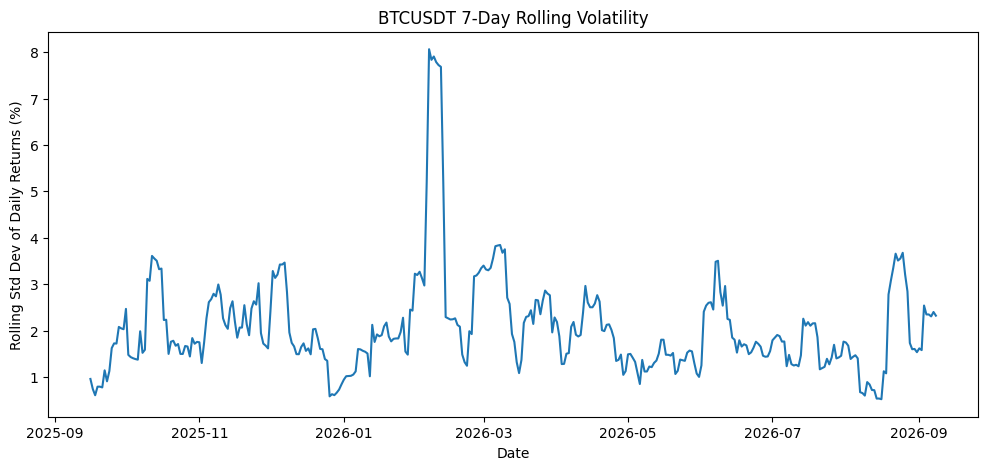

Worst day: 2026-02-05, return: -14.02%


In [3]:
df["rolling_volatility"] = df["daily_return"].rolling(window=7).std()

plt.figure(figsize=(12,5))
plt.plot(df["open_time"], df["rolling_volatility"])
plt.title("BTCUSDT 7-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Std Dev of Daily Returns (%)")
plt.show()

# Find the date of the biggest single-day loss
worst_day = df.loc[df["daily_return"].idxmin()]
print(f"Worst day: {worst_day['open_time'].date()}, return: {worst_day['daily_return']:.2f}%")